# Publication-Ready Figures: RQ1 Sequence-Length Decomposition & RQ4 Cohort Probe (Chapter 6)

Reads `oof_predictions.csv` and `run_summary.json` directly from
`CLASSIFIER/outputs/<exp-id>-seed{42,43,44,45}/latest/`.

1. **Figure 12: Sequence-Length Decomposition** (`fig12_sequence_length_decomposition.pdf`)
   -- RQ1 (§6.2), replaces the two-row reading effort of `tab:rq1-sens`.


In [1]:
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Global publication style settings (.claude/rules/plots.md)
plt.rcParams.update({
    'font.family': 'Courier New',
    'font.size': 8,
    'axes.labelsize': 8.5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

MM = 1 / 25.4
COLOR_GELSTM_FILL, COLOR_GELSTM_EDGE = '#2ba099', '#14605b'      # Teal
COLOR_BTGT_FILL, COLOR_BTGT_EDGE = '#873397', '#50165b'          # Purple

_REPO_ROOT = Path(__file__).resolve().parents[2] if '__file__' in globals() else Path(os.getcwd() if not os.getcwd().endswith('plots_notebooks') else Path(os.getcwd()).parents[1])
CLASSIFIER_ROOT = _REPO_ROOT / 'CLASSIFIER'
OUTPUT_DIRS = [
    _REPO_ROOT / 'THESIS' / 'figures',
    _REPO_ROOT / 'DOCS' / 'results' / 'figures',
]
for d in OUTPUT_DIRS:
    d.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 43, 44, 45]


def resolve_run(prefix, seed):
    latest = CLASSIFIER_ROOT / 'outputs' / f'{prefix}-seed{seed}' / 'latest'
    if latest.exists():
        return latest.resolve()
    raise FileNotFoundError(f'No latest run for {prefix}-seed{seed}.')


print('✓ Environment initialized and output directories ready.')


✓ Environment initialized and output directories ready.


## Ingest: S1 full pool, S1 restricted to ≥ 3 visits, and SENS

S1's own out-of-fold predictions (`tfgn-s1-flip-pooled`) filtered to the 140 subjects
with `n_scans >= 3`, against SENS (`tfgn-sens-minvisits3-pooled`), trained fresh on
exactly that 140-subject pool.


In [2]:
s1_full, s1_restricted, sens_vals = [], [], []
n_restricted = None
for seed in SEEDS:
    run_dir = resolve_run('tfgn-s1-flip-pooled', seed)
    df = pd.read_csv(run_dir / 'oof_predictions.csv')
    s1_full.append(roc_auc_score(df['label'], df['prob']))
    sub = df[df['n_scans'] >= 3]
    n_restricted = len(sub)
    s1_restricted.append(roc_auc_score(sub['label'], sub['prob']))

    sens_dir = resolve_run('tfgn-sens-minvisits3-pooled', seed)
    sens_summary = json.loads((sens_dir / 'run_summary.json').read_text())
    sens_vals.append(sens_summary['oof']['oof_auc'])

decomposition_df = pd.DataFrame({
    'Seed': SEEDS,
    'S1 (full pool, n=248)': s1_full,
    f'S1 restricted to ≥ 3 visits (n={n_restricted})': s1_restricted,
    f'SENS (trained on ≥ 3 visits only, n={n_restricted})': sens_vals,
})
decomposition_df


,Seed,"S1 (full pool, n=248)",S1 restricted to ≥ 3 visits (n=140),"SENS (trained on ≥ 3 visits only, n=140)"
0,42,0.753516,0.776183,0.738506
1,43,0.747156,0.765643,0.749944
2,44,0.748498,0.760260,0.723032
3,45,0.746096,0.782462,0.753532


### Cross-check against `tab:rq1-sens` and the surrounding prose


In [3]:
assert n_restricted == 140, f'expected 140 restricted subjects, got {n_restricted}'

_expected_s1_full = [0.7535, 0.7472, 0.7485, 0.7461]
_expected_s1_restricted = [0.7762, 0.7656, 0.7603, 0.7825]
_expected_sens = [0.7385, 0.7499, 0.7230, 0.7535]

max_abs_diff = 0.0
for got, exp, name in [(s1_full, _expected_s1_full, 'S1 full'),
                        (s1_restricted, _expected_s1_restricted, 'S1 restricted'),
                        (sens_vals, _expected_sens, 'SENS')]:
    diffs = [abs(g - e) for g, e in zip(got, exp)]
    max_abs_diff = max(max_abs_diff, max(diffs))
    assert max(diffs) < 5e-4, f'{name}: {got} vs table {exp}'

assert abs(np.mean(s1_full) - 0.7488) < 5e-4
assert abs(np.mean(s1_restricted) - 0.7712) < 5e-4  # prose: '+0.022' against 0.7488
assert abs(np.mean(sens_vals) - 0.7412) < 5e-4       # prose: 'yields 0.7412'

print(f'✓ All per-seed values match tab:rq1-sens to 4 decimal places (max abs diff {max_abs_diff:.6f}).')
print(f'✓ Restriction effect (+{np.mean(s1_restricted) - np.mean(s1_full):.3f}) and '
      f'retraining effect ({np.mean(sens_vals) - np.mean(s1_restricted):.3f}) match the prose.')


✓ All per-seed values match tab:rq1-sens to 4 decimal places (max abs diff 0.000044).
✓ Restriction effect (+0.022) and retraining effect (-0.030) match the prose.


## Figure 12: Sequence-length decomposition

Two effects in one panel: restricting S1's own predictions to the ≥ 3-visit subset
(same trained model, smaller evaluation pool) against retraining on only that subset
(SENS). The two deltas run in opposite directions and are shown as a single connected
path rather than two separate numbers the reader must hold in mind at once.


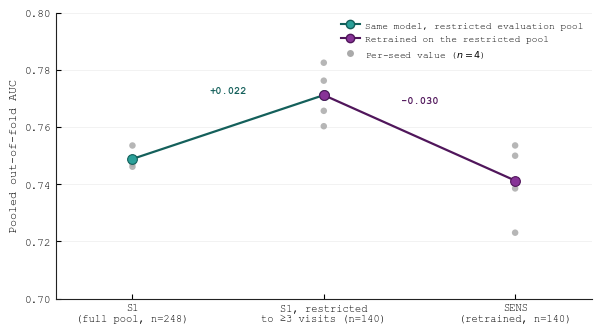

✓ Figure 12 saved successfully.


In [4]:
fig, ax = plt.subplots(figsize=(150 * MM, 82 * MM))

x = np.array([0, 1, 2])
means = [np.mean(s1_full), np.mean(s1_restricted), np.mean(sens_vals)]
labels = ['S1\n(full pool, n=248)', 'S1, restricted\nto ≥3 visits (n=140)', 'SENS\n(retrained, n=140)']

# Per-seed points behind the mean path.
for xi, vals in zip(x, [s1_full, s1_restricted, sens_vals]):
    ax.scatter([xi] * len(vals), vals, s=22, color='#aaaaaa', edgecolor='none', alpha=0.85, zorder=2)

ax.plot(x[:2], means[:2], color=COLOR_GELSTM_EDGE, linewidth=1.6, zorder=3, marker='o',
        markersize=7, markerfacecolor=COLOR_GELSTM_FILL, markeredgecolor=COLOR_GELSTM_EDGE,
        markeredgewidth=0.8, label='Same model, restricted evaluation pool')
ax.plot(x[1:], means[1:], color=COLOR_BTGT_EDGE, linewidth=1.6, zorder=3, marker='o',
        markersize=7, markerfacecolor=COLOR_BTGT_FILL, markeredgecolor=COLOR_BTGT_EDGE,
        markeredgewidth=0.8, label='Retrained on the restricted pool')

ax.annotate(f'+{means[1]-means[0]:.3f}', xy=((x[0]+x[1])/2, (means[0]+means[1])/2 + 0.012),
            ha='center', fontsize=7.5, color=COLOR_GELSTM_EDGE, fontweight='bold')
ax.annotate(f'{means[2]-means[1]:.3f}', xy=((x[1]+x[2])/2, (means[1]+means[2])/2 + 0.012),
            ha='center', fontsize=7.5, color=COLOR_BTGT_EDGE, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel('Pooled out-of-fold AUC')
ax.set_xlim(-0.4, 2.4)
ax.set_ylim(0.70, 0.80)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')
ax.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax.set_axisbelow(True)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color=COLOR_GELSTM_EDGE, markerfacecolor=COLOR_GELSTM_FILL,
           markersize=6, label='Same model, restricted evaluation pool'),
    Line2D([0], [0], marker='o', color=COLOR_BTGT_EDGE, markerfacecolor=COLOR_BTGT_FILL,
           markersize=6, label='Retrained on the restricted pool'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#aaaaaa', markeredgecolor='none',
           markersize=5, label='Per-seed value ($n=4$)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=6.8, handletextpad=0.5)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig12_sequence_length_decomposition.pdf', facecolor='white', edgecolor='none')
    fig.savefig(out_dir / 'fig12_sequence_length_decomposition.png', dpi=600, facecolor='white', edgecolor='none')

plt.show()
print('✓ Figure 12 saved successfully.')
